# Array Indexing Image

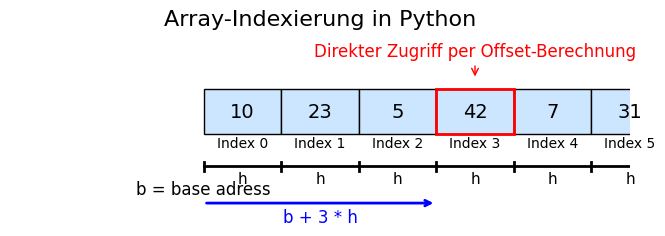

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Werte und Indizes
values = ['10', '23', '5', '42', '7', '31']
indices = list(range(len(values)))

fig, ax = plt.subplots(figsize=(8, 2.5))
ax.set_xlim(-2.5, 5.5)
ax.set_ylim(-2, 2.2)
ax.axis('off')

# Array-Zellen zeichnen
for i, val in enumerate(values):
    rect = patches.Rectangle((i, 0), 1, 1, fill=True, edgecolor='black', facecolor='#cce6ff')
    ax.add_patch(rect)
    ax.text(i+0.5, 0.5, val, va='center', ha='center', fontsize=14)
    ax.text(i+0.5, -0.2, f"Index {i}", va='center', ha='center', fontsize=10)

# Beispiel: Index 3 hervorheben
ax.add_patch(patches.Rectangle((3, 0), 1, 1, fill=False, edgecolor='red', linewidth=2))
ax.annotate("Direkter Zugriff per Offset-Berechnung", xy=(3.5, 1.2), xytext=(3.5, 1.7),
            arrowprops=dict(arrowstyle="->", color='red'), ha='center', fontsize=12, color='red')

# h-Linien und Beschriftungen zeichnen
for i in range(len(values)):
    x_start = i
    x_end = i+1
    y = -0.7
    ax.plot([x_start, x_end], [y, y], color='black', linewidth=2)
    ax.plot([x_start, x_start], [y+0.1, y-0.1], color='black', linewidth=2)
    ax.text((x_start+x_end)/2, y-0.1, "h", ha='center', va='top', fontsize=11)
ax.text(0, -1.0, "b = base adress", ha='center', va='top', fontsize=12)
plt.title("Array-Indexierung in Python", fontsize=16)

# Pfeil am Start von Index 3 mit Beschriftung
ax.annotate("", xy=(3, -1.5), xytext=(0, -1.5),
            arrowprops=dict(arrowstyle="->", color='blue', linewidth=2))
ax.text(1.5, -1.6, "b + 3 * h", ha='center', va='top', fontsize=12, color='blue')
plt.savefig('array_indexing.png', bbox_inches='tight')
plt.show()

# Hash Tables

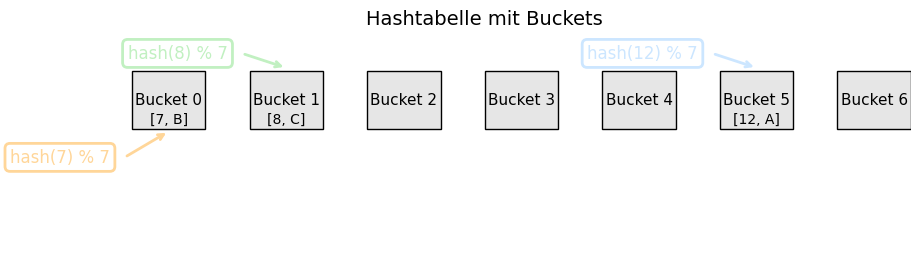

In [48]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

n_buckets = 7
bucket_distance = 1.6  # Abstand zwischen den Buckets
bucket_positions = [i * bucket_distance for i in range(n_buckets)]

beispielpaare = [(12, 'A'), (7, 'B'), (8, 'C')]
farben = ['#cce6ff', '#ffd699', '#c1f0c1', '#f0b3ff']

fig, ax = plt.subplots(figsize=(11, 3))
ax.set_xlim(-1, bucket_positions[-1] + 1)
ax.set_ylim(-2, 2)
ax.axis('off')

# Buckets zeichnen
for i, xpos in enumerate(bucket_positions):
    rect = patches.Rectangle((xpos, 0), 1, 1, fill=True, edgecolor='black', facecolor='#e6e6e6')
    ax.add_patch(rect)
    ax.text(xpos + 0.5, 0.5, f"Bucket {i}", va='center', ha='center', fontsize=11)

# Beispielhafte Einträge und Pfeile
for idx, (key, val) in enumerate(beispielpaare):
    bucket_idx = hash(key) % n_buckets
    xpos = bucket_positions[bucket_idx]
    if (-1)**idx >= 0:
        ax.text(xpos-0.3, (-1)**idx * 1.3, f"hash({key}) % {n_buckets}", ha='right', va='center', fontsize=12, color=farben[idx % len(farben)], bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=farben[idx % len(farben)], lw=2))
        ax.annotate("", xy=(xpos + 0.5, 1.05), xytext=(xpos-0.1, (-1)**idx * 1.3), arrowprops=dict(arrowstyle="->", color=farben[idx % len(farben)], lw=2))
    else:
        ax.text(xpos-0.3, (-1)**idx * 0.5, f"hash({key}) % {n_buckets}", ha='right', va='center', fontsize=12, color=farben[idx % len(farben)], bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=farben[idx % len(farben)], lw=2))
        ax.annotate("", xy=(xpos + 0.5, -.05), xytext=(xpos-0.1, (-1)**idx * 0.5), arrowprops=dict(arrowstyle="->", color=farben[idx % len(farben)], lw=2))
    
    ax.text(xpos + 0.5, 0.15, f"[{key}, {val}]", va='center', ha='center', fontsize=10, color="black")

ax.text(bucket_positions[-1] / 2, 1.8, "Hashtabelle mit Buckets", ha='center', fontsize=14)
plt.savefig('hash_table_buckets.png', bbox_inches='tight')
plt.show()

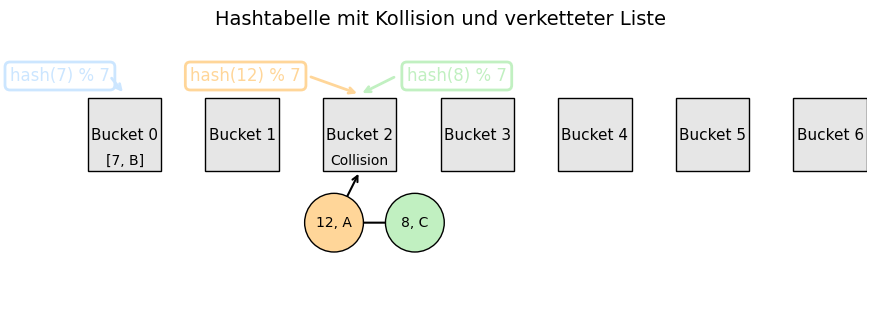

In [85]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

n_buckets = 7
bucket_distance = 1.6  # Abstand zwischen den Buckets
bucket_positions = [i * bucket_distance for i in range(n_buckets)]

# Wir wählen Keys so, dass 12 und 8 auf Bucket 2 kollidieren:
beispielpaare = [(7, 'B'),(12, 'A'), (8, 'C')]
farben = ['#cce6ff', '#ffd699', '#c1f0c1']

fig, ax = plt.subplots(figsize=(11, 4))
ax.set_xlim(-1, bucket_positions[-1] + 1)
ax.set_ylim(-2, 2.2)
ax.axis('off')

# Buckets zeichnen
for i, xpos in enumerate(bucket_positions):
    rect = patches.Rectangle((xpos, 0), 1, 1, fill=True, edgecolor='black', facecolor='#e6e6e6')
    ax.add_patch(rect)
    ax.text(xpos + 0.5, 0.5, f"Bucket {i}", va='center', ha='center', fontsize=11)

# Einträge und Pfeile
# Key 7
ax.text(0.3, 1.3, f"hash({7}) % {n_buckets}", ha='right', va='center', fontsize=12, color=farben[0], bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=farben[0], lw=2))
ax.annotate("", xy=(bucket_positions[0] + .5, 1.05), xytext=(bucket_positions[0]+0.3, 1.3), arrowprops=dict(arrowstyle="->", color=farben[0], lw=2))
ax.text(bucket_positions[0] + 0.5, 0.15, f"[{7}, B]", va='center', ha='center', fontsize=10, color="black")
# Key 12 and 8 collide in Bucket 2
ax.text(bucket_positions[2] - 0.3, 1.3, f"hash({12}) % {n_buckets}", ha='right', va='center', fontsize=12, color=farben[1], bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=farben[1], lw=2))
ax.text(bucket_positions[2] + 2.5, 1.3, f"hash({8}) % {n_buckets}", ha='right', va='center', fontsize=12, color=farben[2], bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=farben[2], lw=2))
ax.annotate("", xy=(bucket_positions[2] + .5, 1.05), xytext=(bucket_positions[2]-0.2, 1.3), arrowprops=dict(arrowstyle="->", color=farben[1], lw=2))
ax.annotate("", xy=(bucket_positions[2] + .5, 1.05), xytext=(bucket_positions[2]+1.0, 1.3), arrowprops=dict(arrowstyle="->", color=farben[2], lw=2))
ax.text(bucket_positions[2] + 0.5, 0.15, f"Collision", va='center', ha='center', fontsize=10, color="black")

# Verkettete Liste für Bucket 2 zeichnen
x_bucket2 = bucket_positions[2] + 0.5
y_bucket = 0
node_radius = 0.4
# Knoten-Positionen für [12, 'A'] und [8, 'C']
knoten = [ (x_bucket2-0.35, y_bucket-0.7), (x_bucket2+0.75, y_bucket-0.7)]
for i, (key, val) in enumerate([(12, 'A'), (8, 'C')]):
    circle = plt.Circle(knoten[i], node_radius, color=farben[i+1], ec='black', zorder=10)
    ax.add_patch(circle)
    ax.text(knoten[i][0], knoten[i][1], f"{key}, {val}", ha='center', va='center', fontsize=10, zorder=11)
# Pfeil von Bucket nach erstem Knoten
ax.annotate("", xy=(x_bucket2, 0), xytext=knoten[0], arrowprops=dict(arrowstyle="->", lw=1.5, color='black'))
# Pfeil von erstem zu zweitem Knoten
ax.annotate("", xy=knoten[1], xytext=knoten[0], arrowprops=dict(arrowstyle="->", lw=1.5, color='black'))

ax.text(bucket_positions[-1] / 2, 2, "Hashtabelle mit Kollision und verketteter Liste", ha='center', fontsize=14)
plt.savefig('hash_table_collision.png', bbox_inches='tight')
plt.show()